#   HW1 - Introduction to Image Processing Course



### 1. Environment Setup and Preparations

**Import libraries**

In [34]:
import sys
import os
import cv2
import random
import matplotlib.pyplot as plt
from matplotlib.image import imread, imsave
import pandas as pd
import numpy as np
import tensorflow as tf
import skimage as ski
from skimage.io import imread
from skimage import img_as_float
from skimage import exposure
from PIL import Image

**Libraries versions**

In [35]:
print('pandas version: '+ pd.__version__)
print('numpy version: '+np.__version__)
print('tensorflow version: '+tf.__version__)
print('scikit-image version: '+ski.__version__)

pandas version: 2.2.2
numpy version: 1.26.4
tensorflow version: 2.17.0
scikit-image version: 0.24.0


In [36]:
conda_env = os.environ.get('CONDA_DEFAULT_ENV')
print(f"current Conda environment: '{conda_env}'.")

current Conda environment: 'image_processing_env'.


`image_common_utils` functions

In [37]:
# Description: It displays many images in one row
def imshow_all(*images, titles=None):
    images = [img_as_float(img) for img in images]

    if titles is None:
        titles = [''] * len(images)
    vmin = min(map(np.min, images))
    vmax = max(map(np.max, images))
    ncols = len(images)
    height = 5
    width = height * len(images)
    fig, axes = plt.subplots(nrows=1, ncols=ncols, figsize=(width, height))
    for ax, img, label in zip(axes.ravel(), images, titles):
        ax.imshow(img, vmin=vmin, vmax=vmax)
        ax.set_title(label)

    return
    # end of imshow_all

# Description: It displays many images in many rows and column
# cmap='gray'; row_plot = 1; img= [img, camera]
def show_image(img, cmap='gray', row_plot = 1):
    if not isinstance(img, list):
        img = [img]

    if len(img) == 1:
        plt.imshow(img[0], cmap=cmap) # cm.gray
    else:
        # Get column count
        col_plot = len(img) // row_plot
        fig, axes = plt.subplots(row_plot, col_plot)
        for count in range(len(img)): # count= 1
            axes[count].imshow(img[count], cmap=cmap)
    plt.show()
    return
# end of show_image


`import_image` function to import images

In [38]:
def import_image (path):
    img = imread(path)
    img.shape  # H x W x C
    img.size  # multiplication of HxWxC
    type(img)
    img.dtype
    return(img)

Import all images from `image_data` folder

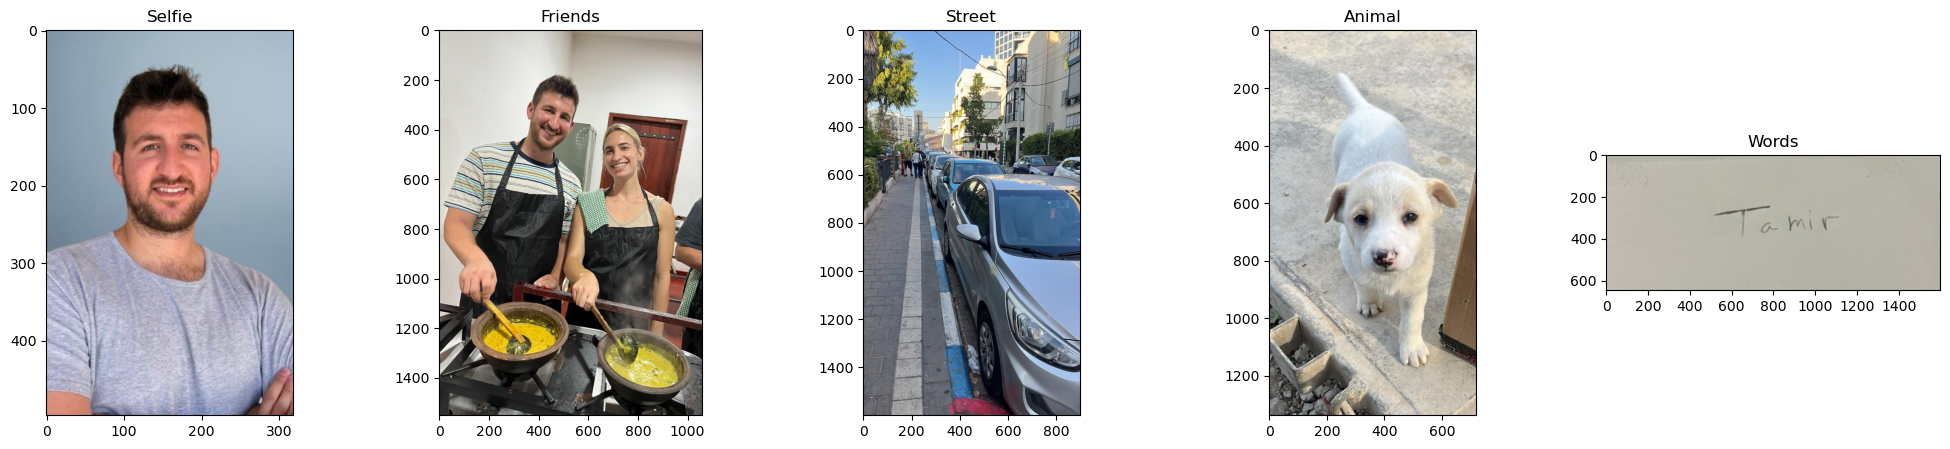

In [39]:
selfie = import_image('./images_data/selfie.jpg')
friends = import_image('./images_data/friends.jpg')
street = import_image('./images_data/street.jpg')
animal = import_image('./images_data/animal.jpg')
words = import_image('./images_data/words.jpg')

imshow_all(selfie, friends, street, animal, words, titles=["Selfie", "Friends", "Street", "Animal", "Words"])

### 2. Image Formats and Color Schemes

Import the wanted image

In [40]:
selfie = import_image('./images_data/selfie.jpg')

Loop function to iterate all the different color schemes and file formats and save them

In [41]:
def change_color_scheme(image, base_name):

    # Define the color schemes and file formats in a dictionary
    color_schemes = {
        "RGB": lambda img: cv2.cvtColor(img, cv2.COLOR_BGR2RGB),
        "GRAYSCALE": lambda img: cv2.cvtColor(img, cv2.COLOR_BGR2GRAY),
        "HSL": lambda img: cv2.cvtColor(img, cv2.COLOR_BGR2HLS),
        "CYMK": lambda img: cv2.cvtColor(img, cv2.COLOR_BGR2RGB),  # PIL handles CMYK later
    }
    file_formats = [".tiff", ".jpeg", ".png", ".gif"]

    for scheme_name, conversion in color_schemes.items():
        try:
            # Convert the image
            converted_image = conversion(image)

            # Special handling for CMYK
            cmyk_image = None
            if scheme_name == "CYMK":
                converted_image = Image.fromarray(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
                cmyk_image = converted_image.convert("CMYK")

            # Save each image by different format
            for file_format in file_formats:
                try:
                    output_image_name = f"{base_name}_{scheme_name}{file_format}"

                    if scheme_name == "CYMK" and cmyk_image:
                        if file_format == ".gif":
                            cmyk_image.convert("RGB").save(output_image_name, format="GIF")
                        else:
                            cmyk_image.save(output_image_name)
                    else:
                        if len(converted_image.shape) == 2 and file_format != ".gif":  # Grayscale image
                            converted_image_to_save = cv2.cvtColor(converted_image, cv2.COLOR_GRAY2BGR)
                        else:
                            converted_image_to_save = converted_image

                        if file_format == ".gif":
                            Image.fromarray(cv2.cvtColor(converted_image_to_save, cv2.COLOR_BGR2RGB)).save(output_image_name, format="GIF")
                        else:
                            cv2.imwrite(output_image_name, converted_image_to_save)

                    print(f"Saved: {output_image_name}")
                except Exception as e:
                    print(f"Could not save {scheme_name} in {file_format}: {e}")
        except Exception as e:
            print(f"Could not convert to {scheme_name}: {e}")
    return


**Color shcemes**


In [42]:
change_color_scheme(selfie,"selfie")

Saved: selfie_RGB.tiff
Saved: selfie_RGB.jpeg
Saved: selfie_RGB.png
Saved: selfie_RGB.gif
Saved: selfie_GRAYSCALE.tiff
Saved: selfie_GRAYSCALE.jpeg
Saved: selfie_GRAYSCALE.png
Saved: selfie_GRAYSCALE.gif
Saved: selfie_HSL.tiff
Saved: selfie_HSL.jpeg
Saved: selfie_HSL.png
Saved: selfie_HSL.gif
Saved: selfie_CYMK.tiff
Saved: selfie_CYMK.jpeg
Could not save CYMK in .png: cannot write mode CMYK as PNG
Saved: selfie_CYMK.gif


**HEX file format**

function to convert an image from rgb to hex, then to save it as a csv file

In [43]:
def rgb_to_hex(rgb):
    return "#{:02x}{:02x}{:02x}".format(int(rgb[0]), int(rgb[1]), int(rgb[2]))

def image_to_hex_csv(image, csv_filename):

    # Convert image to a 2D array of HEX colors
    hex_matrix = np.array([[rgb_to_hex(tuple(pixel)) for pixel in row] for row in image])

    # Flatten and create a DataFrame of HEX colors
    hex_colors = hex_matrix.reshape(-1)
    hex_df = pd.DataFrame(hex_colors, columns=['Hex Color'])

    # Save to CSV
    hex_df.to_csv(csv_filename, index=False)
    print(f"Hex color codes saved to {csv_filename}")

    return hex_matrix

**CSV file**

In [44]:
hex_matrix = image_to_hex_csv(selfie, 'selfie_hex_colors.csv')
print(hex_matrix)

Hex color codes saved to selfie_hex_colors.csv
[['#7c91a2' '#7c91a2' '#7c91a2' ... '#a7bac8' '#a8bbc9' '#a9bcca']
 ['#7c91a2' '#7c91a2' '#7d92a3' ... '#a6b9c7' '#a7bac8' '#a8bbc9']
 ['#7c91a2' '#7d92a3' '#7d92a3' ... '#a6b9c7' '#a6b9c7' '#a6b9c7']
 ...
 ['#da8f78' '#da8f78' '#da8f78' ... '#804b3b' '#7e4937' '#804837']
 ['#dc9079' '#db9079' '#dc9079' ... '#7b4636' '#7a4533' '#7d4836']
 ['#dd8f79' '#db8f78' '#dc8e78' ... '#814c3c' '#834e3e' '#855040']]


### 3. Upscaling and Downscaling

Upscaling & Downscaling functions

In [45]:
def upscale_image(image, base_name):
   
    # Get original dimensions
    original_height, original_width = image.shape[:2]

    # Calculate new dimensions to be x2 the size
    new_height = original_height * 2
    new_width = original_width * 2

    # Upscale the image
    upscaled_image = cv2.resize(image, (new_width, new_height), interpolation=cv2.INTER_CUBIC)

    # Print new dimensions
    print(f"New upscaled dimensions: {new_width}x{new_height}")

    # Save the upscaled image
    save_path = f"{base_name}_upscale.jpeg"
    cv2.imwrite(save_path, cv2.cvtColor(upscaled_image, cv2.COLOR_RGB2BGR))

    return(upscale_image)


def downscale_image(image, base_name):
   
    # Get original dimensions
    original_height, original_width = image.shape[:2]

    # Calculate new dimensions to be x0.5 the size
    new_height = int(original_height * 0.5)
    new_width = int(original_width * 0.5)

    # Upscale the image
    downscaled_image = cv2.resize(image, (new_width, new_height), interpolation=cv2.INTER_CUBIC)

    # Print new dimensions
    print(f"New downscaled dimensions: {new_width}x{new_height}")

    # Save the upscaled image
    save_path = f"{base_name}_downscale.jpeg"
    cv2.imwrite(save_path, cv2.cvtColor(downscaled_image, cv2.COLOR_RGB2BGR))

    return(downscale_image)


The dimensions of the regular, upsacled and downscaled images

In [46]:
print(f"Regular dimensions: {selfie.shape[1]}x{selfie.shape[0]}")
upscale_selfie = upscale_image(selfie, "selfie")
downscale_selfie = downscale_image(selfie, "selfie") 

Regular dimensions: 319x497
New upscaled dimensions: 638x994
New downscaled dimensions: 159x248


**Upsacled and downscaled images**

with grids on

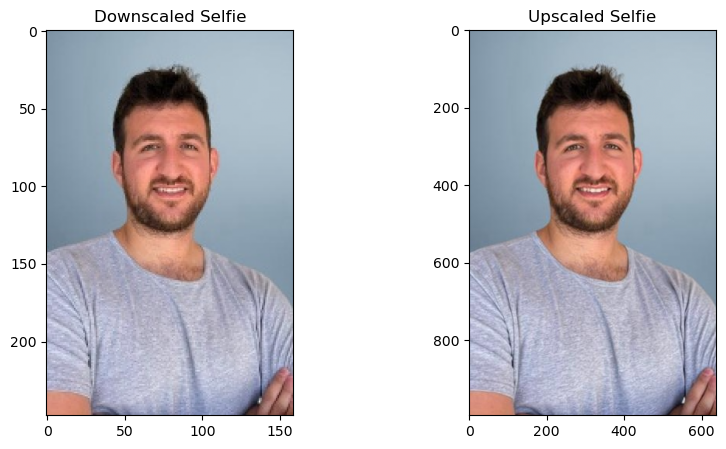

In [47]:
downscaled_selfie = import_image('selfie_downscale.jpeg')
upscaled_selfie = import_image('selfie_upscale.jpeg')

imshow_all(downscaled_selfie, upscaled_selfie, titles=["Downscaled Selfie", "Upscaled Selfie"])

### 4. Shape Drawing

Function to draw a rectangle on an image based on the mouse coordinates.

 Press 'r' to reset the image and 'esc' to quit

In [48]:
# Global variables
point1 = None
point2 = None
rectangle_defined = False

# Function to draw the rectangle using the mouse coordinates
def draw_rectangle(event, x, y, flags, param):
    global point1, point2, rectangle_defined

    if event == cv2.EVENT_LBUTTONDOWN:
        if point1 is None:
            # First click defines the first corner of the rectangle
            point1 = (x, y)
        elif point2 is None:
            # Second click defines the opposite corner
            point2 = (x, y)
            rectangle_defined = True

# Create a black image
img = np.zeros((512, 512, 3), np.uint8)
backup_img = img.copy()  # Backup image to reset drawing

# Name the window
cv2.namedWindow(winname='rectangle_drawer')

# Connect the mouse callback to the window
cv2.setMouseCallback('rectangle_drawer', draw_rectangle)

while True:
    display_img = backup_img.copy()

    # If both points are defined, draw the rectangle
    if point1 is not None and point2 is not None:
        cv2.rectangle(display_img, point1, point2, (0, 255, 0), 2)

    # Display the image
    cv2.imshow('rectangle_drawer', display_img)

    # Wait for key press
    key = cv2.waitKey(1) & 0xFF

    if key == 27 or key == ord('q'):  # ESC or 'q' to exit
        break
    elif key == ord('r'):  # 'r' to reset the image
        point1, point2 = None, None
        rectangle_defined = False

# Cleanup
cv2.destroyAllWindows()

QObject::moveToThread: Current thread (0x57e37af3e440) is not the object's thread (0x57e37ae0c420).
Cannot move to target thread (0x57e37af3e440)

QObject::moveToThread: Current thread (0x57e37af3e440) is not the object's thread (0x57e37ae0c420).
Cannot move to target thread (0x57e37af3e440)

QObject::moveToThread: Current thread (0x57e37af3e440) is not the object's thread (0x57e37ae0c420).
Cannot move to target thread (0x57e37af3e440)

QObject::moveToThread: Current thread (0x57e37af3e440) is not the object's thread (0x57e37ae0c420).
Cannot move to target thread (0x57e37af3e440)

QObject::moveToThread: Current thread (0x57e37af3e440) is not the object's thread (0x57e37ae0c420).
Cannot move to target thread (0x57e37af3e440)

QObject::moveToThread: Current thread (0x57e37af3e440) is not the object's thread (0x57e37ae0c420).
Cannot move to target thread (0x57e37af3e440)

QObject::moveToThread: Current thread (0x57e37af3e440) is not the object's thread (0x57e37ae0c420).
Cannot move to tar

### 5. Video Annotation

Function to annotate each frame with the average green value and save 3 random frames.

In [49]:
def annotate_video():
    
    # Input video path
    input_video = './images_data/horse.mp4'

    # Open the video file
    cap = cv2.VideoCapture(input_video)

    # Get video properties
    frame_width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    frame_height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    fps = int(cap.get(cv2.CAP_PROP_FPS))
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')

    # Output video path (same directory as the code)
    output_path = os.path.join(os.getcwd(), 'horse_annotated.mp4')

    # Define the output video writer
    out = cv2.VideoWriter(output_path, fourcc, fps, (frame_width, frame_height))

    # Generate random frame indices to save
    random_frame_indices = sorted(random.sample(range(total_frames), 3))
    saved_frame_count = 0

    frame_index = 0

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        # Extract the green channel
        green_channel = frame[:, :, 1]

        # Define the bottom-right corner
        corner_height = frame_height // 10
        corner_width = frame_width // 10
        bottom_right_corner = green_channel[-corner_height:, -corner_width:]

        # Calculate the average green value
        avg_green = np.mean(bottom_right_corner)

        # Annotate the frame with the average green value
        annotated_text = f"Avg Green: {avg_green:.2f}"
        text_size = 1  # Make text larger
        text_thickness = 2  # Make text bold
        text_position = (frame_width - 300, frame_height - 30)  # Bottom-right corner
        cv2.putText(frame, annotated_text, text_position,
                    cv2.FONT_HERSHEY_SIMPLEX, text_size, (0, 255, 0), text_thickness, cv2.LINE_AA)

        # Write the annotated frame to the output video
        out.write(frame)

        # Save random frames
        if frame_index in random_frame_indices:
            saved_frame_path = os.path.join(os.getcwd(), f"frame_{frame_index}.jpg")
            cv2.imwrite(saved_frame_path, frame)
            saved_frame_count += 1

        frame_index += 1

        # Stop if all random frames are saved
        if saved_frame_count >= 3:
            random_frame_indices = []

    # Release resources
    cap.release()
    out.release()
    cv2.destroyAllWindows()


In [50]:
annotate_video()

### 6. Image Histogram Analysis

Functions to analysis and print the histograms for each channel of an image seperatly and combined.

In [51]:
# Normalize the values by the max value
def normalize_cdf(cdf):
    return cdf / np.max(cdf)

def plot_histograms_and_cdfs(image, channel_labels=['Red', 'Green', 'Blue']):
    # Split the image into color channels
    b, g, r = cv2.split(image)

    # Calculate histograms
    hist_r, bins_r = np.histogram(r.flatten(), bins=256, range=[0, 256], density=False)
    hist_g, bins_g = np.histogram(g.flatten(), bins=256, range=[0, 256], density=False)
    hist_b, bins_b = np.histogram(b.flatten(), bins=256, range=[0, 256], density=False)

    # Calculate cumulative distribution functions (CDFs)
    cdf_r = normalize_cdf(np.cumsum(hist_r))
    cdf_g = normalize_cdf(np.cumsum(hist_g))
    cdf_b = normalize_cdf(np.cumsum(hist_b))

    # Plot histograms and overlay normalized CDFs for each channel
    plt.figure(figsize=(12, 6))

    # Plot histograms with primary y-axis
    plt.subplot(1, 3, 1)
    plt.bar(bins_r[:-1], hist_r, color='red', alpha=0.5, width=1)
    plt.title(f'{channel_labels[0]} Channel Histogram')
    plt.xlabel('Pixel Intensity')
    plt.ylabel('Number of Pixels')

    # Create a secondary y-axis for normalized CDFs
    ax1 = plt.gca()
    ax2 = ax1.twinx()

    # Plot normalized CDF on the secondary y-axis
    ax2.plot(bins_r[:-1], cdf_r, color='blue', label='Normalized CDF', linestyle='--')
    ax2.set_ylabel('Normalized Cumulative Distribution Function', color='blue')

    # Plot histograms with primary y-axis
    plt.subplot(1, 3, 2)
    plt.bar(bins_g[:-1], hist_g, color='green', alpha=0.5, width=1)
    plt.title(f'{channel_labels[1]} Channel Histogram')
    plt.xlabel('Pixel Intensity')
    plt.ylabel('Number of Pixels')

    # Create a secondary y-axis for normalized CDFs
    ax1 = plt.gca()
    ax2 = ax1.twinx()

    # Plot normalized CDF on the secondary y-axis
    ax2.plot(bins_g[:-1], cdf_g, color='blue', label='Normalized CDF', linestyle='--')
    ax2.set_ylabel('Normalized Cumulative Distribution Function', color='blue')

    # Plot histograms with primary y-axis
    plt.subplot(1, 3, 3)
    plt.bar(bins_b[:-1], hist_b, color='blue', alpha=0.5, width=1)
    plt.title(f'{channel_labels[2]} Channel Histogram')
    plt.xlabel('Pixel Intensity')
    plt.ylabel('Number of Pixels')

    # Create a secondary y-axis for normalized CDFs
    ax1 = plt.gca()
    ax2 = ax1.twinx()

    # Plot normalized CDF on the secondary y-axis
    ax2.plot(bins_b[:-1], cdf_b, color='blue', label='Normalized CDF', linestyle='--')
    ax2.set_ylabel('Normalized Cumulative Distribution Function', color='blue')

    plt.tight_layout()
    plt.show()

def plot_joint_histogram_and_cdf(image, channel_labels=['Red', 'Green', 'Blue']):
    # Split the image into color channels
    b, g, r = cv2.split(image)

    # Calculate histograms
    hist_r, bins_r = np.histogram(r.flatten(), bins=256, range=[0, 256], density=False)
    hist_g, bins_g = np.histogram(g.flatten(), bins=256, range=[0, 256], density=False)
    hist_b, bins_b = np.histogram(b.flatten(), bins=256, range=[0, 256], density=False)

    # Calculate cumulative distribution functions (CDFs)
    cdf_r = normalize_cdf(np.cumsum(hist_r))
    cdf_g = normalize_cdf(np.cumsum(hist_g))
    cdf_b = normalize_cdf(np.cumsum(hist_b))

    # Calculate joint cumulative distribution function (CDF)
    cdf_joint = (cdf_r + cdf_g + cdf_b) / 3

    # Plot histograms and overlay normalized CDFs for each channel in the same graph
    plt.figure(figsize=(12, 6))

    # Plot histograms
    plt.bar(bins_r[:-1], hist_r, color='red', alpha=0.5, width=1, label=f'{channel_labels[0]} Channel')
    plt.bar(bins_g[:-1], hist_g, color='green', alpha=0.5, width=1, label=f'{channel_labels[1]} Channel')
    plt.bar(bins_b[:-1], hist_b, color='blue', alpha=0.5, width=1, label=f'{channel_labels[2]} Channel')

    # Create a secondary y-axis for normalized CDFs
    ax1 = plt.gca()
    ax2 = ax1.twinx()

    # Plot CDFs on the secondary y-axis
    ax2.plot(bins_r[:-1], cdf_r, color='red', label=f'{channel_labels[0]} Channel CDF', linestyle='--')
    ax2.plot(bins_g[:-1], cdf_g, color='green', label=f'{channel_labels[1]} Channel CDF', linestyle='--')
    ax2.plot(bins_b[:-1], cdf_b, color='blue', label=f'{channel_labels[2]} Channel CDF', linestyle='--')

    # Plot joint CDF in solid black
    ax2.plot(bins_r[:-1], cdf_joint, color='black', label='Joint CDF')

    ax2.set_ylabel('Normalized Cumulative Distribution Function', color='black')
    ax2.tick_params(axis='y', labelcolor='black')

    plt.title('Normalized Histograms and Cumulative Distribution Functions for RGB Channels')
    plt.xlabel('Pixel Intensity')
    plt.ylabel('Number of Pixels')

    plt.legend(loc='upper left')
    plt.tight_layout()
    plt.show()

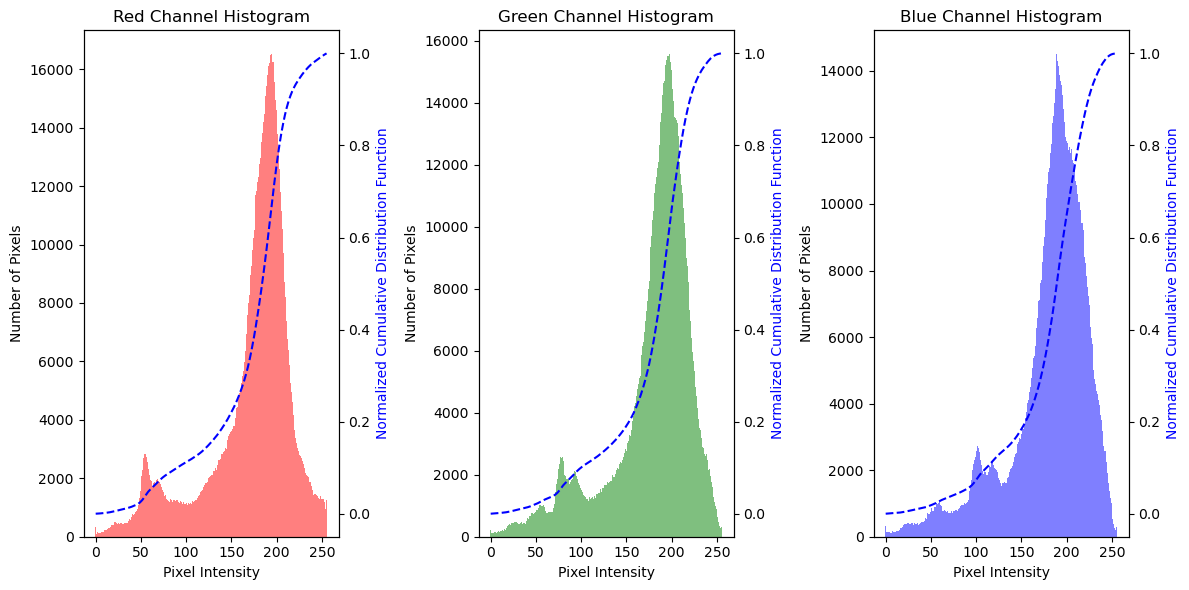

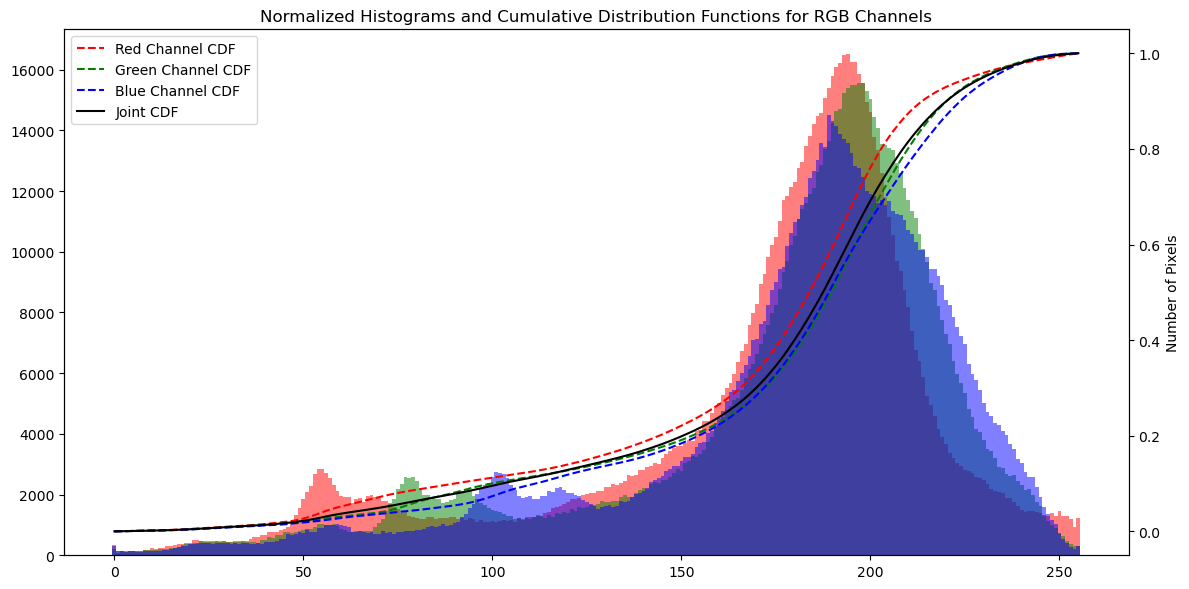

In [52]:
plot_histograms_and_cdfs(animal)
plot_joint_histogram_and_cdf(animal)

**Thresholded Images**

Function to print a darkened image using threshold mask

In [53]:
def dark_image(image, base_name):
    # Split the image into color channels
    b, g, r = cv2.split(image)

    # Set a threshold for darkening (adjust as needed)
    threshold_value = 180

    # Apply THRESH_TOZERO to each channel separately
    r_dark = cv2.threshold(r, threshold_value, 255, cv2.THRESH_TOZERO)[1]
    g_dark = cv2.threshold(g, threshold_value, 255, cv2.THRESH_TOZERO)[1]
    b_dark = cv2.threshold(b, threshold_value, 255, cv2.THRESH_TOZERO)[1]

    # Merge the darkened channels back into an image
    dark_image = cv2.merge([b_dark, g_dark, r_dark])

    # Display the original and darkened images
    plt.figure(figsize=(10, 5))

    plt.subplot(1, 2, 1)
    plt.imshow(image)
    plt.title('Original Image')

    plt.subplot(1, 2, 2)
    plt.imshow(dark_image)
    plt.title('Dark Image')

    plt.show()

    # Save the new image
    output_path = os.path.join(f"{base_name}_dark.jpeg")
    imsave(output_path, dark_image)

    return dark_image

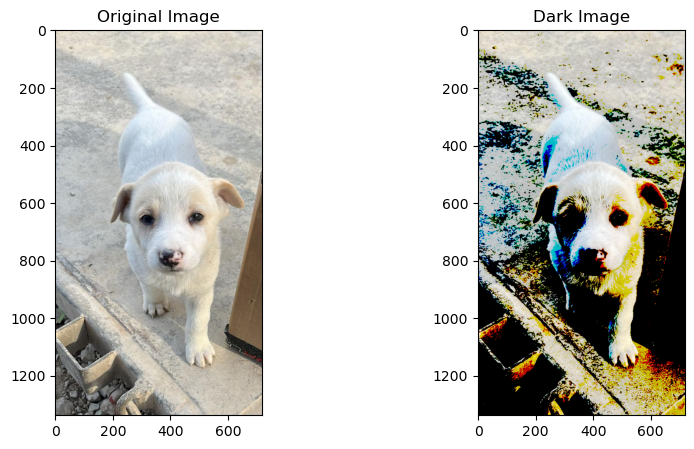

In [54]:
dark_animal = dark_image(animal, "animal")

Function to print a brightened image using threshold mask

In [55]:
def bright_image(image, base_name):
    # Split the image into color channels
    b, g, r = cv2.split(image)

    # Set a threshold for brightening(adjust as needed)
    threshold_value = 10

    # Apply THRESH_TOZERO to each channel separately
    r_bright = cv2.threshold(r, threshold_value, 255, cv2.THRESH_TOZERO)[1]
    g_bright = cv2.threshold(g, threshold_value, 255, cv2.THRESH_TOZERO)[1]
    b_bright = cv2.threshold(b, threshold_value, 255, cv2.THRESH_TOZERO)[1]

    # Merge the brighten channels back into an image
    bright_image = cv2.merge([b_bright, g_bright, r_bright])

    # Display the original and brighten images
    plt.figure(figsize=(10, 5))

    plt.subplot(1, 2, 1)
    plt.imshow(image)
    plt.title('Original Image')

    plt.subplot(1, 2, 2)
    plt.imshow(bright_image)
    plt.title('Bright Image')

    plt.show()

    # Save the new image
    output_path = os.path.join(f"{base_name}_bright.jpeg")
    imsave(output_path, bright_image)

    return bright_image

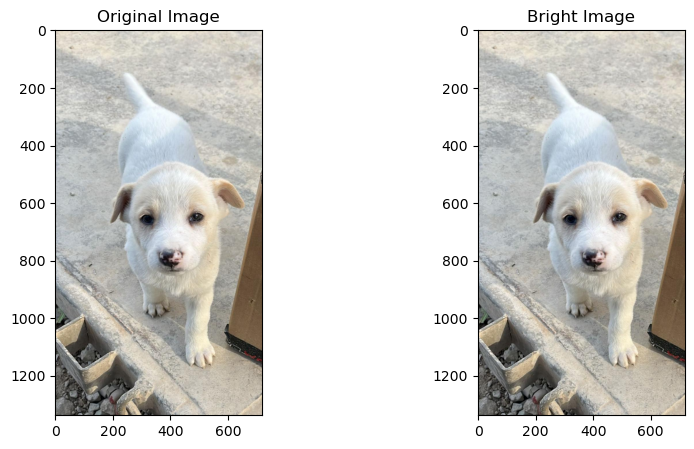

In [56]:
bright_animal = bright_image(animal, "animal")

**Log transformation**

In [57]:
def apply_log(image, base_name):
   
    def log_trans_band(band):
        x = 255 / np.log(1 + np.max(band))
        log_x_band = x * (np.log(band + 1))
        log_x_band = np.array(log_x_band, dtype=np.uint8)
        return log_x_band

    # Split the image into color channels
    b_band, g_band, r_band = cv2.split(image)

    # Apply log transformation to each channel
    log_b_band = log_trans_band(b_band)
    log_g_band = log_trans_band(g_band)
    log_r_band = log_trans_band(r_band)

    # Merge the transformed channels back into an image
    log_image = cv2.merge([log_b_band, log_g_band, log_r_band])

    # Convert the original image to RGB format
    original_rgb =(image)

    # Convert the log-transformed image to RGB format
    transformed_rgb =(log_image)

    # Plot the original and the new image side by side
    plt.figure(figsize=(10, 5))

    plt.subplot(1, 2, 1)
    plt.imshow(original_rgb)
    plt.title('Original Image')
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(transformed_rgb)
    plt.title('Image after Log Transformation')
    plt.axis('off')
    plt.show()

    # Save the new image
    output_path = os.path.join(f"{base_name}_log_transformation.jpeg")
    imsave(output_path, transformed_rgb)

    return log_image

/tmp/ipykernel_25204/3973204941.py:5: RuntimeWarning: divide by zero encountered in log
  log_x_band = x * (np.log(band + 1))
/tmp/ipykernel_25204/3973204941.py:6: RuntimeWarning: invalid value encountered in cast
  log_x_band = np.array(log_x_band, dtype=np.uint8)


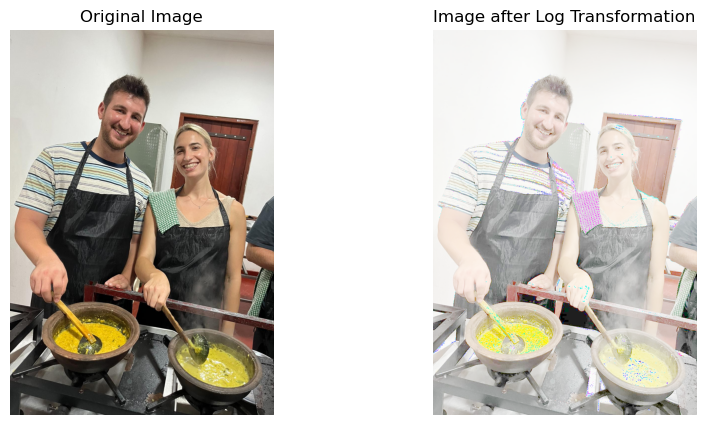

In [58]:
log_friends= apply_log(friends, "friends")

**Contrast Limited Adaptive Histogram Equalization (CLAHE)**

In [59]:
def apply_clahe(image, base_name):
  
    # Split the image into color channels
    b_band, g_band, r_band = cv2.split(image)

    # Create CLAHE objects for each channel
    b_clahe = cv2.createCLAHE(clipLimit=5)
    g_clahe = cv2.createCLAHE(clipLimit=5)
    r_clahe = cv2.createCLAHE(clipLimit=5)

    # Apply CLAHE to each channel
    final_b_clahe = b_clahe.apply(b_band)
    final_g_clahe = g_clahe.apply(g_band)
    final_r_clahe = r_clahe.apply(r_band)

    # Merge the CLAHE-processed channels back into an image
    img_clahe = cv2.merge((final_b_clahe, final_g_clahe, final_r_clahe))

    # Convert the original image to RGB format
    original_rgb = (image)

    # Convert the CLAHE-processed image to RGB format
    clahe_rgb = (img_clahe)

    # Display both images in the same plot
    plt.figure(figsize=(12, 6))

    # Plot original image
    plt.subplot(1, 2, 1)
    plt.imshow(original_rgb)
    plt.title('Original Image')
    plt.axis('off')

    # Plot processed image
    plt.subplot(1, 2, 2)
    plt.imshow(clahe_rgb)
    plt.title('CLAHE Processed Image')
    plt.axis('off')

    # Show the plot
    plt.show()

    # Save the processed image
    output_path = os.path.join(f"{base_name}_clahe.jpeg")
    imsave(output_path, clahe_rgb)

    return img_clahe


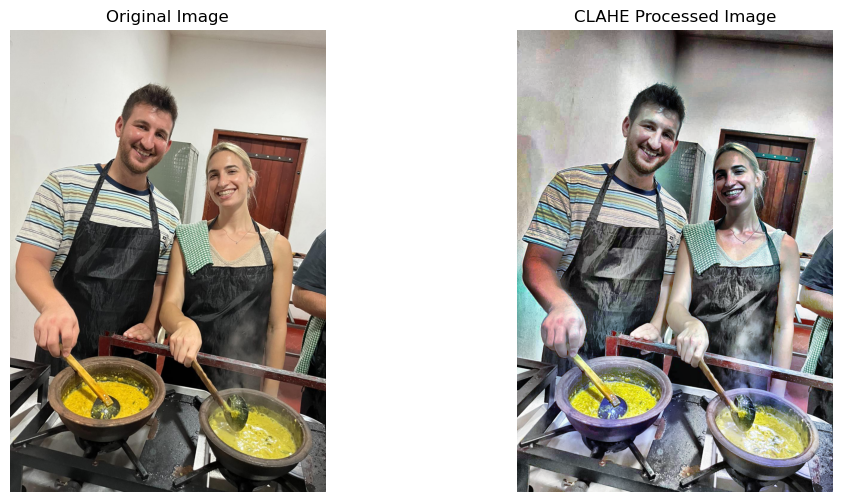

In [60]:
clahe_friends = apply_clahe(friends, "friends")

**Contrast Enhancement by Histogram Equalization**

In [61]:
def apply_enhance_contrast(image, base_name):
  
    # Split the image into color channels
    b_band, g_band, r_band = cv2.split(image)

    # Convert to 8-bit unsigned integer
    b_band = b_band.astype(np.uint8)
    g_band = g_band.astype(np.uint8)
    r_band = r_band.astype(np.uint8)

    # Apply histogram equalization to each channel
    equalized_b = exposure.equalize_hist(b_band)
    equalized_g = exposure.equalize_hist(g_band)
    equalized_r = exposure.equalize_hist(r_band)

    # Convert back to 8-bit unsigned integer
    equalized_b = (equalized_b * 255).astype(np.uint8)
    equalized_g = (equalized_g * 255).astype(np.uint8)
    equalized_r = (equalized_r * 255).astype(np.uint8)

    # Merge the equalized channels back into an image
    enhanced_image = cv2.merge((equalized_b, equalized_g, equalized_r))

    # Convert the original image to RGB format
    original_rgb = (image)

    # Convert the enhanced image to RGB format
    enhanced_rgb = (enhanced_image)

    # Display both images in the same plot
    plt.figure(figsize=(12, 6))

    # Plot original image
    plt.subplot(1, 2, 1)
    plt.imshow(original_rgb)
    plt.title('Original Image')
    plt.axis('off')

    # Plot enhanced image
    plt.subplot(1, 2, 2)
    plt.imshow(enhanced_rgb)
    plt.title('Contrast Enhanced Image')
    plt.axis('off')

    # Show the plot
    plt.show()

    # Save the enhanced image
    output_path = os.path.join(f"{base_name}_contrast_enhanced.jpeg")
    imsave(output_path, enhanced_rgb)

    return enhanced_image

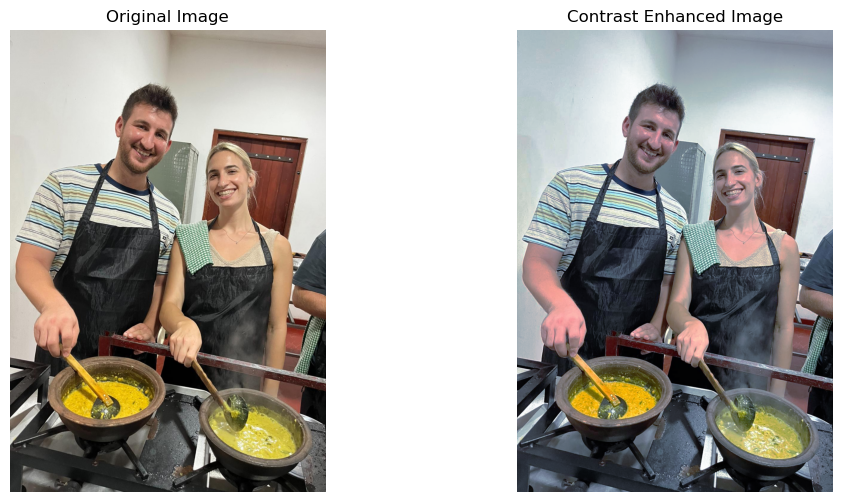

In [62]:
enhance_friends = apply_enhance_contrast(friends, "friends")